In [13]:
%%markdown
Estimating the causal effect requires four steps:

- Model a causal inference problem using assumptions.

- Identify an expression for the causal effect under these assumptions (“causal estimand”).

- Estimate the expression using statistical methods such as matching or instrumental variables.

- Finally, verify the validity of the estimate using a variety of robustness checks.


This workflow is captured by four key verbs in DoWhy:

- model (CausalModel or graph)

- identify (identify_effect)

- estimate (estimate_effect)

- refute (refute_estimate)


Ref: https://www.pywhy.org/dowhy/v0.12/user_guide/causal_tasks/estimating_causal_effects/index.html


Estimating the causal effect requires four steps:

- Model a causal inference problem using assumptions.

- Identify an expression for the causal effect under these assumptions (“causal estimand”).

- Estimate the expression using statistical methods such as matching or instrumental variables.

- Finally, verify the validity of the estimate using a variety of robustness checks.


This workflow is captured by four key verbs in DoWhy:

- model (CausalModel or graph)

- identify (identify_effect)

- estimate (estimate_effect)

- refute (refute_estimate)


Ref: https://www.pywhy.org/dowhy/v0.12/user_guide/causal_tasks/estimating_causal_effects/index.html


In [ ]:
from dowhy import CausalModel
import dowhy.datasets

import networkx as nx
import matplotlib.pyplot as plt



# Generate some sample data
data = dowhy.datasets.linear_dataset(
    beta=10,
    num_common_causes=5,
    num_instruments=2,
    num_samples=10000)


c:\Users\LucasAbreu\.conda\envs\pymc_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [16]:
data.keys()

dict_keys(['df', 'treatment_name', 'outcome_name', 'common_causes_names', 'instrument_names', 'effect_modifier_names', 'frontdoor_variables_names', 'dot_graph', 'gml_graph', 'ate'])

In [14]:
data['df']

,Z0,Z1,W0,W1,W2,W3,W4,v0,y,propensity_score
0,0.0,0.421788,0.286915,-0.729431,0.510190,-0.323666,-0.302426,True,10.831952,0.952294
1,1.0,0.856182,0.708387,-3.384539,0.262747,1.184159,-1.050869,True,10.779808,0.986310
2,1.0,0.887713,0.874268,0.104865,1.216406,-0.887278,-0.676164,True,13.784865,0.976383
3,1.0,0.027813,1.345346,0.552131,0.216183,0.903620,1.183100,True,16.113819,0.999033
4,0.0,0.758504,-1.393995,-1.226334,2.087026,-1.740317,0.677564,True,10.809923,0.635147
...,...,...,...,...,...,...,...,...,...,...
9995,0.0,0.134910,-0.676422,-0.438016,2.688771,-0.769087,1.541807,True,17.296391,0.982177
9996,1.0,0.847216,-0.646352,-0.258638,1.230532,-0.881480,1.204098,True,11.981994,0.924047
9997,0.0,0.830475,-1.335681,0.242283,2.486488,-0.734825,0.546637,True,15.458353,0.927994
9998,1.0,0.799714,0.153469,-0.357373,0.579556,-1.396182,0.644986,True,9.712497,0.889836


In [17]:
data['treatment_name']

['v0']

In [18]:
data['outcome_name']

'y'

In [20]:
print(data['gml_graph'])

graph[directed 1node[ id "y" label "y"]node[ id "W0" label "W0"] node[ id "W1" label "W1"] node[ id "W2" label "W2"] node[ id "W3" label "W3"] node[ id "W4" label "W4"]node[ id "Z0" label "Z0"] node[ id "Z1" label "Z1"]node[ id "v0" label "v0"]edge[source "v0" target "y"]edge[ source "W0" target "v0"] edge[ source "W1" target "v0"] edge[ source "W2" target "v0"] edge[ source "W3" target "v0"] edge[ source "W4" target "v0"]edge[ source "Z0" target "v0"] edge[ source "Z1" target "v0"]edge[ source "W0" target "y"] edge[ source "W1" target "y"] edge[ source "W2" target "y"] edge[ source "W3" target "y"] edge[ source "W4" target "y"]]


In [23]:
# Step 1: Create a causal model from the data and given graph.
model = CausalModel(
    data=data["df"],
    treatment=data["treatment_name"],
    outcome=data["outcome_name"],
    graph=data["gml_graph"])


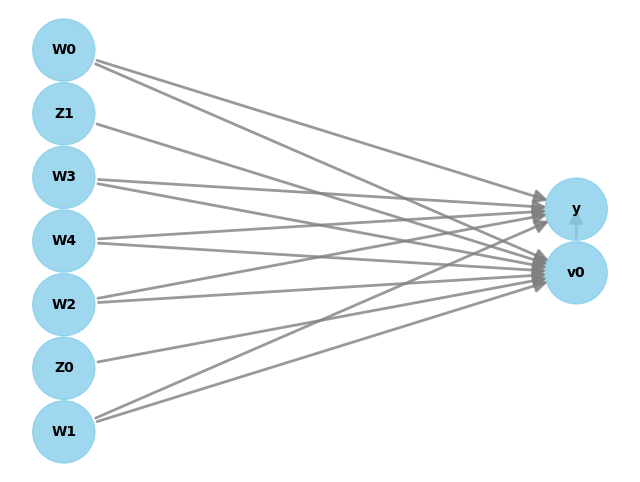

In [44]:
model.view_model()

In [24]:
model.summary()

"Model to find the causal effect of treatment ['v0'] on outcome ['y']"

In [26]:

# Step 2: Identify causal effect and return target estimands
identified_estimand = model.identify_effect()


In [45]:
print(identified_estimand)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
  d                       
─────(E[y|W1,W2,W4,W3,W0])
d[v₀]                     
Estimand assumption 1, Unconfoundedness: If U→{v0} and U→y then P(y|v0,W1,W2,W4,W3,W0,U) = P(y|v0,W1,W2,W4,W3,W0)

### Estimand : 2
Estimand name: iv
Estimand expression:
 ⎡                              -1⎤
 ⎢    d        ⎛    d          ⎞  ⎥
E⎢─────────(y)⋅⎜─────────([v₀])⎟  ⎥
 ⎣d[Z₀  Z₁]    ⎝d[Z₀  Z₁]      ⎠  ⎦
Estimand assumption 1, As-if-random: If U→→y then ¬(U →→{Z0,Z1})
Estimand assumption 2, Exclusion: If we remove {Z0,Z1}→{v0}, then ¬({Z0,Z1}→y)

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!



In [34]:

# Step 3: Estimate the target estimand using a statistical method.
estimate = model.estimate_effect(identified_estimand,
                                 method_name="backdoor.propensity_score_matching")


In [46]:
print(estimate)

*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
  d                       
─────(E[y|W1,W2,W4,W3,W0])
d[v₀]                     
Estimand assumption 1, Unconfoundedness: If U→{v0} and U→y then P(y|v0,W1,W2,W4,W3,W0,U) = P(y|v0,W1,W2,W4,W3,W0)

## Realized estimand
b: y~v0+W1+W2+W4+W3+W0
Target units: ate

## Estimate
Mean value: 9.55544530463867



In [40]:

# Step 4: Refute the obtained estimate using multiple robustness checks.
refute_results = model.refute_estimate(identified_estimand, estimate,
                                       method_name="random_common_cause")

In [47]:
print(refute_results)

Refute: Add a random common cause
Estimated effect:9.55544530463867
New effect:9.555445304638667
p value:1.0

